# Q1 Use a Python notebook & Load the dataseta Python notebook & Load the dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
colnames = ['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)','MDVP:Jitter(Abs)','MDVP:RAP','MDVP:PPQ','Jitter:DDP','MDVP:Shimmer','MDVP:Shimmer(dB)','Shimmer:APQ3','Shimmer:APQ5','MDVP:APQ','Shimmer:DDA','NHR','HNR','status','RPDE','D2','DFA','spread1','spread2','PPE']
p_df = pd.read_csv("18052019_parkinsons.data", names= colnames)

# Q2 eye-ball row data

In [3]:
p_df.shape

(196, 24)

In [4]:
cols = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',  
'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5','MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1',
'spread2', 'D2', 'PPE']
p_df[cols] = p_df[cols].apply(pd.to_numeric, errors='coerce', axis=1)

In [5]:
p_df.dtypes

name                 object
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status               object
RPDE                float64
D2                  float64
DFA                 float64
spread1             float64
spread2             float64
PPE                 float64
dtype: object

In [6]:
from pandas.tools.plotting import scatter_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

In [7]:
# No columns have null data in the file
p_df.apply(lambda x : sum(x.isnull()))

name                0
MDVP:Fo(Hz)         1
MDVP:Fhi(Hz)        1
MDVP:Flo(Hz)        1
MDVP:Jitter(%)      1
MDVP:Jitter(Abs)    1
MDVP:RAP            1
MDVP:PPQ            1
Jitter:DDP          1
MDVP:Shimmer        1
MDVP:Shimmer(dB)    1
Shimmer:APQ3        1
Shimmer:APQ5        1
MDVP:APQ            1
Shimmer:DDA         1
NHR                 1
HNR                 1
status              0
RPDE                1
D2                  1
DFA                 1
spread1             1
spread2             1
PPE                 1
dtype: int64

In [8]:
# Eye balling the data
p_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [9]:
p_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 24 columns):
name                196 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              196 non-null object
RPDE                195 non-null float64
D2                  195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null flo

In [10]:
#status - Health status of the subject (one) - Parkinson's, (zero) - healthy
p_df.groupby('status').count()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,D2,DFA,spread1,spread2,PPE
status,,,,,,,,,,,,,,,,,,,,,
0,48,48,48,48,48,48,48,48,48,48,...,48,48,48,48,48,48,48,48,48,48
1,147,147,147,147,147,147,147,147,147,147,...,147,147,147,147,147,147,147,147,147,147
status,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# check whether the column has any value other than numeric values
p_df.iloc[:,1:][~p_df.iloc[:,1:].applymap(np.isreal).all(1)]

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,D2,DFA,spread1,spread2,PPE
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,status,NaN,NaN,NaN,NaN,NaN,NaN
1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
6,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,0.456,...,0.06985,0.01222,21.378,1,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
7,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,0.140,...,0.02337,0.00607,24.886,1,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
8,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,0.134,...,0.02487,0.00344,26.892,1,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
9,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,0.191,...,0.03218,0.01070,21.812,1,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571


In [12]:
p_df.dropna(axis=0, how='any', thresh=None, subset=None, inplace=True)

In [13]:
print (p_df)

               name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
1    phon_R01_S01_1      119.992       157.302        74.997         0.00784   
2    phon_R01_S01_2      122.400       148.650       113.819         0.00968   
3    phon_R01_S01_3      116.682       131.111       111.555         0.01050   
4    phon_R01_S01_4      116.676       137.871       111.366         0.00997   
5    phon_R01_S01_5      116.014       141.781       110.655         0.01284   
6    phon_R01_S01_6      120.552       131.162       113.787         0.00968   
7    phon_R01_S02_1      120.267       137.244       114.820         0.00333   
8    phon_R01_S02_2      107.332       113.840       104.315         0.00290   
9    phon_R01_S02_3       95.730       132.068        91.754         0.00551   
10   phon_R01_S02_4       95.056       120.103        91.226         0.00532   
11   phon_R01_S02_5       88.333       112.240        84.072         0.00505   
12   phon_R01_S02_6       91.904       1

In [14]:
# No columns have null data in the file
p_df.apply(lambda x : sum(x.isnull()))

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
D2                  0
DFA                 0
spread1             0
spread2             0
PPE                 0
dtype: int64

In [15]:
#finding unique data
p_df.apply(lambda x: len(x.unique()))

name                195
MDVP:Fo(Hz)         195
MDVP:Fhi(Hz)        195
MDVP:Flo(Hz)        195
MDVP:Jitter(%)      173
MDVP:Jitter(Abs)     19
MDVP:RAP            155
MDVP:PPQ            165
Jitter:DDP          180
MDVP:Shimmer        188
MDVP:Shimmer(dB)    149
Shimmer:APQ3        184
Shimmer:APQ5        189
MDVP:APQ            189
Shimmer:DDA         189
NHR                 185
HNR                 195
status                2
RPDE                195
D2                  195
DFA                 195
spread1             194
spread2             195
PPE                 195
dtype: int64

In [16]:
p_df.corr()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,D2,DFA,spread1,spread2,PPE
MDVP:Fo(Hz),1.000000,0.400985,0.596546,-0.118003,-0.382027,-0.076194,-0.112165,-0.076213,-0.098374,-0.073742,...,-0.077774,-0.094732,-0.021981,0.059144,-0.383894,-0.446013,-0.413738,-0.249450,0.177980,-0.372356
MDVP:Fhi(Hz),0.400985,1.000000,0.084951,0.102086,-0.029198,0.097177,0.091126,0.097150,0.002281,0.043465,...,0.004937,-0.003733,0.163766,-0.024893,-0.112404,-0.343097,-0.076658,-0.002954,0.176323,-0.069543
MDVP:Flo(Hz),0.596546,0.084951,1.000000,-0.139919,-0.277815,-0.100519,-0.095828,-0.100488,-0.144543,-0.119089,...,-0.107293,-0.150737,-0.108670,0.210851,-0.400143,-0.050406,-0.394857,-0.243829,-0.100629,-0.340071
MDVP:Jitter(%),-0.118003,0.102086,-0.139919,1.000000,0.935714,0.990276,0.974256,0.990276,0.769063,0.804289,...,0.758255,0.746635,0.906959,-0.728165,0.360673,0.098572,0.693577,0.385123,0.433434,0.721543
MDVP:Jitter(Abs),-0.382027,-0.029198,-0.277815,0.935714,1.000000,0.922911,0.897778,0.922913,0.703322,0.716601,...,0.648793,0.697170,0.834972,-0.656810,0.441839,0.175036,0.735779,0.388543,0.310694,0.748162
MDVP:RAP,-0.076194,0.097177,-0.100519,0.990276,0.922911,1.000000,0.957317,1.000000,0.759581,0.790652,...,0.737455,0.744919,0.919521,-0.721543,0.342140,0.064083,0.648328,0.324407,0.426605,0.670999
MDVP:PPQ,-0.112165,0.091126,-0.095828,0.974256,0.897778,0.957317,1.000000,0.957319,0.797826,0.839239,...,0.804139,0.763592,0.844604,-0.731510,0.333274,0.196301,0.716489,0.407605,0.412524,0.769647
Jitter:DDP,-0.076213,0.097150,-0.100488,0.990276,0.922913,1.000000,0.957319,1.000000,0.759555,0.790621,...,0.737439,0.744901,0.919548,-0.721494,0.342079,0.064026,0.648328,0.324377,0.426556,0.671005
MDVP:Shimmer,-0.098374,0.002281,-0.144543,0.769063,0.703322,0.759581,0.797826,0.759555,1.000000,0.987258,...,0.950083,0.987626,0.722194,-0.835271,0.447424,0.159954,0.654734,0.452025,0.507088,0.693771
MDVP:Shimmer(dB),-0.073742,0.043465,-0.119089,0.804289,0.716601,0.790652,0.839239,0.790621,0.987258,1.000000,...,0.960977,0.963202,0.744477,-0.827805,0.410684,0.165157,0.652547,0.454314,0.512233,0.695058


# Q3 univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails

In [17]:
# Univariate Analysis
p_df.kurtosis(numeric_only  = True)

MDVP:Fo(Hz)         -0.627898
MDVP:Fhi(Hz)         7.627241
MDVP:Flo(Hz)         0.654615
MDVP:Jitter(%)      12.030939
MDVP:Jitter(Abs)    10.869043
MDVP:RAP            14.213798
MDVP:PPQ            11.963922
Jitter:DDP          14.224762
MDVP:Shimmer         3.238308
MDVP:Shimmer(dB)     5.128193
Shimmer:APQ3         2.720152
Shimmer:APQ5         3.874210
MDVP:APQ            11.163288
Shimmer:DDA          2.720661
NHR                 21.994974
HNR                  0.616036
RPDE                -0.921781
D2                  -0.686152
DFA                 -0.050199
spread1             -0.083023
spread2              0.220334
PPE                  0.528335
dtype: float64

In [18]:
p_df.skew(numeric_only  = True)

MDVP:Fo(Hz)         0.591737
MDVP:Fhi(Hz)        2.542146
MDVP:Flo(Hz)        1.217350
MDVP:Jitter(%)      3.084946
MDVP:Jitter(Abs)    2.649071
MDVP:RAP            3.360708
MDVP:PPQ            3.073892
Jitter:DDP          3.362058
MDVP:Shimmer        1.666480
MDVP:Shimmer(dB)    1.999389
Shimmer:APQ3        1.580576
Shimmer:APQ5        1.798697
MDVP:APQ            2.618047
Shimmer:DDA         1.580618
NHR                 4.220709
HNR                -0.514317
RPDE               -0.143402
D2                 -0.033214
DFA                 0.432139
spread1             0.144430
spread2             0.430384
PPE                 0.797491
dtype: float64

Skewness with positive values indicates data is skewed towards right. Skewness with negative values indicates data is skewed towards left

Average vocal fundamental frequency MDVP:Fo(Hz)

In [19]:
print("The average vocal fundamental frequency of a person is {:.2f} and 99% of the people have a Fo of {:.2f}".format(p_df['MDVP:Fo(Hz)'].mean(),p_df['MDVP:Fo(Hz)'].quantile(0.90)))

The average vocal fundamental frequency of a person is 154.23 and 99% of the people have a Fo of 209.89


In [20]:
p_df['MDVP:Fo(Hz)'].plot(kind='box')

Skewness :  0.5917374636540784
Kurtosis :  -0.6278981066788805
AxesSubplot(0.125,0.125;0.775x0.755)


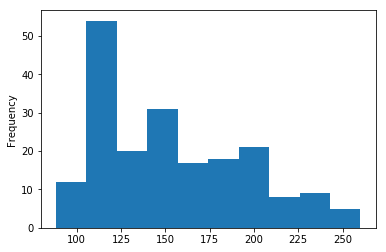

In [21]:
print('Skewness : ',p_df['MDVP:Fo(Hz)'].skew())
print('Kurtosis : ',p_df['MDVP:Fo(Hz)'].kurtosis())
print(p_df['MDVP:Fo(Hz)'].plot.hist())


The value is positive hence the data is skewed towards right side

The value is negative hence less data points are around the tail

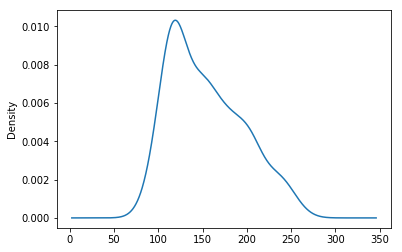

In [22]:
p_df['MDVP:Fo(Hz)'].plot.kde()

Maximum vocal fundamental frequency MDVP:Fhi (Hz)

In [23]:
print("The maximum vocal fundamental frequency of a person is {:.2f} and 99% of the people have a Fhi of {:.2f}".format(p_df['MDVP:Fhi(Hz)'].mean(),p_df['MDVP:Fhi(Hz)'].quantile(0.90)))

The maximum vocal fundamental frequency of a person is 197.10 and 99% of the people have a Fhi of 261.00


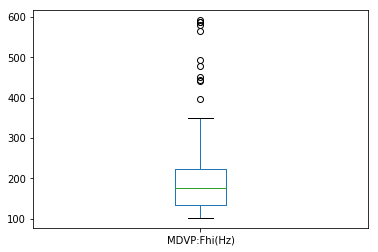

In [24]:
p_df['MDVP:Fhi(Hz)'].plot(kind='box')

Skewness :  2.542145997588398
Kurtosis :  7.627241211631889
AxesSubplot(0.125,0.125;0.775x0.755)


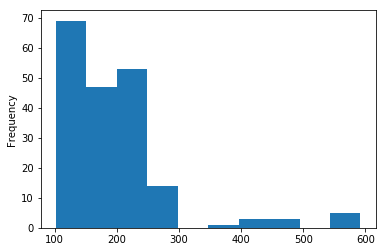

In [25]:
print('Skewness : ',p_df['MDVP:Fhi(Hz)'].skew())
print('Kurtosis : ',p_df['MDVP:Fhi(Hz)'].kurtosis())
print(p_df['MDVP:Fhi(Hz)'].plot.hist(bins=10))


The value is positive hence the data is skewed towards right side

The value is postive hence more data points are around the tail

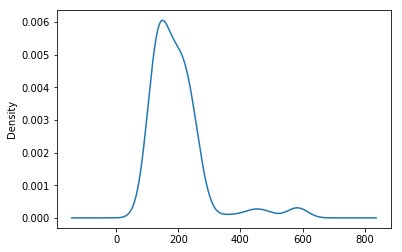

In [26]:
p_df['MDVP:Fhi(Hz)'].plot.kde()

Outlier Treatment

In [27]:
q3 = p_df['MDVP:Fhi(Hz)'].quantile(0.75)
q1 = p_df['MDVP:Fhi(Hz)'].quantile(0.25)
t = q3-q1
outliers_above = q3+t
outliers_below = q1-t
print("outliers_above : {}".format(outliers_above))
print("outliers_below : {}".format(outliers_below))

outliers_above : 313.5485
outliers_below : 45.51950000000002


In [28]:
print(p_df['MDVP:Fhi(Hz)'].loc[p_df['MDVP:Fhi(Hz)']>outliers_above].count())
print(p_df['MDVP:Fhi(Hz)'].loc[p_df['MDVP:Fhi(Hz)']<outliers_below].count())
print(p_df['MDVP:Fhi(Hz)'].loc[p_df['MDVP:Fhi(Hz)']>outliers_above])

12
0
17     349.259
74     588.518
103    586.567
116    492.892
117    442.557
118    450.247
119    442.824
121    479.697
150    565.740
187    592.030
188    581.289
194    396.961
Name: MDVP:Fhi(Hz), dtype: float64


In [29]:
mean_val = p_df['MDVP:Fhi(Hz)'].loc[p_df['MDVP:Fhi(Hz)']<=outliers_above].mean()
p_df['MDVP:Fhi(Hz)'] = p_df['MDVP:Fhi(Hz)'].mask(p_df['MDVP:Fhi(Hz)']>outliers_above,mean_val)
print(p_df['MDVP:Fhi(Hz)'].head(20))

1     157.302000
2     148.650000
3     131.111000
4     137.871000
5     141.781000
6     131.162000
7     137.244000
8     113.840000
9     132.068000
10    120.103000
11    112.240000
12    115.871000
13    159.866000
14    179.139000
15    163.305000
16    217.455000
17    177.414634
18    232.181000
19    175.829000
20    189.398000
Name: MDVP:Fhi(Hz), dtype: float64


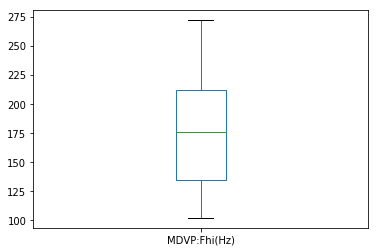

In [30]:
p_df['MDVP:Fhi(Hz)'].plot(kind='box')

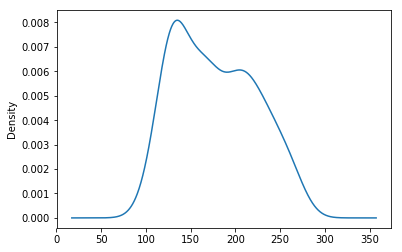

In [31]:
p_df['MDVP:Fhi(Hz)'].plot.kde()

Skewness :  0.2984561761401523
Kurtosis :  -1.0462818430124097


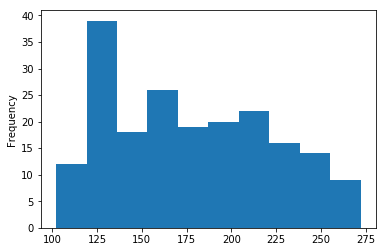

In [32]:
print('Skewness : ',p_df['MDVP:Fhi(Hz)'].skew())
print('Kurtosis : ',p_df['MDVP:Fhi(Hz)'].kurtosis())
p_df['MDVP:Fhi(Hz)'].plot.hist()

After outlier treatment kurtosis indicates that less number of data points are around the tail

Minimum vocal fundamental frequency MDVP:Flo (Hz)

In [33]:
print("The minimum vocal fundamental frequency of a person is {:.2f} and 99% of the people have a Flo of {:.2f}".format(p_df['MDVP:Flo(Hz)'].mean(),p_df['MDVP:Flo(Hz)'].quantile(0.90)))


The minimum vocal fundamental frequency of a person is 116.32 and 99% of the people have a Flo of 187.88


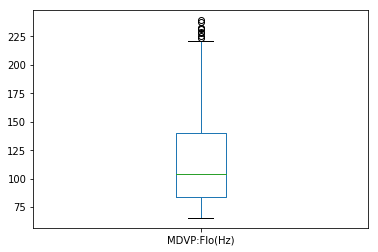

In [34]:
p_df['MDVP:Flo(Hz)'].plot(kind='box')

Skewness :  1.217350448627808
Kurtosis :  0.6546145211395396
AxesSubplot(0.125,0.125;0.775x0.755)


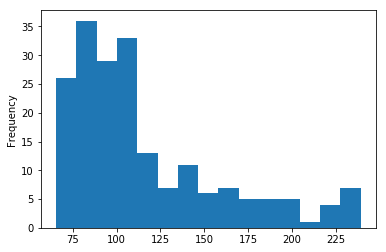

In [35]:
print('Skewness : ',p_df['MDVP:Flo(Hz)'].skew())
print('Kurtosis : ',p_df['MDVP:Flo(Hz)'].kurtosis())
print(p_df['MDVP:Flo(Hz)'].plot.hist(bins=15))


The value is positive hence the data is skewed towards right side

The value is postive hence the more data points are around the tail

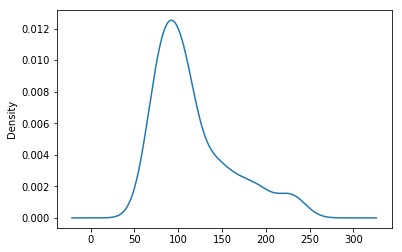

In [36]:
 p_df['MDVP:Flo(Hz)'].plot.kde()   

Outlier Treatment

In [37]:
q3 = p_df['MDVP:Flo(Hz)'].quantile(0.75)
q1 = p_df['MDVP:Flo(Hz)'].quantile(0.25)
t = q3-q1
outliers_above = q3+t
outliers_below = q1-t
print("outliers_above : {}".format(outliers_above))
print("outliers_below : {}".format(outliers_below))

outliers_above : 195.74600000000004
outliers_below : 28.563499999999976


In [38]:
print(p_df['MDVP:Flo(Hz)'].loc[p_df['MDVP:Flo(Hz)']>outliers_above].count())
print(p_df['MDVP:Flo(Hz)'].loc[p_df['MDVP:Flo(Hz)']<outliers_below].count())
print(p_df['MDVP:Flo(Hz)'].loc[p_df['MDVP:Flo(Hz)']>outliers_above])

15
0
34     197.079
35     196.160
43     225.227
44     232.483
45     232.435
46     227.911
47     231.848
63     205.495
64     223.634
65     221.156
112    199.020
167    229.256
168    237.303
170    219.783
171    239.170
Name: MDVP:Flo(Hz), dtype: float64


AxesSubplot(0.125,0.125;0.775x0.755)


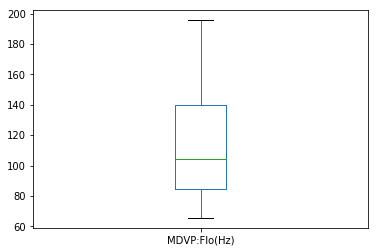

In [39]:
max_val = p_df['MDVP:Flo(Hz)'].loc[p_df['MDVP:Flo(Hz)']<=outliers_above].max()
p_df['MDVP:Flo(Hz)'] = p_df['MDVP:Flo(Hz)'].mask(p_df['MDVP:Flo(Hz)']>outliers_above,max_val)
print(p_df['MDVP:Flo(Hz)'].plot(kind='box'))

Skewness :  0.9105008789129816
Kurtosis :  -0.3380621656813876
AxesSubplot(0.125,0.125;0.775x0.755)


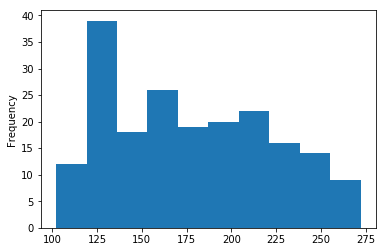

In [40]:
print('Skewness : ',p_df['MDVP:Flo(Hz)'].skew())
print('Kurtosis : ',p_df['MDVP:Flo(Hz)'].kurtosis())
print(p_df['MDVP:Fhi(Hz)'].plot.hist())

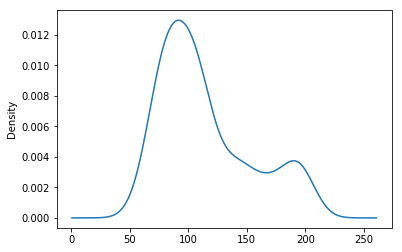

In [41]:
p_df['MDVP:Flo(Hz)'].plot.kde()

After outlier treatment kurtosis indicates less number of data points around the tail

Five measures of variation in fundamental frequency

MDVP:Jitter(%)

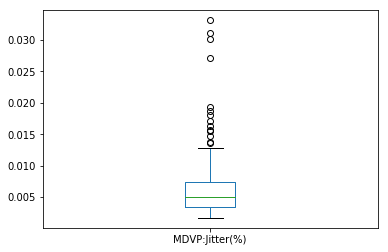

In [42]:
p_df ['MDVP:Jitter(%)'].plot(kind='box')

In [43]:
print("The minimum vocal fundamental frequency of a person is {:.2f} and 99% of the people have a Jitter of {:.2f}".format(p_df['MDVP:Jitter(%)'].mean(),p_df['MDVP:Jitter(%)'].quantile(0.90)))

The minimum vocal fundamental frequency of a person is 0.01 and 99% of the people have a Jitter of 0.01


Skewness :  3.0849462014441817
Kurtosis :  12.030939276179508
AxesSubplot(0.125,0.125;0.775x0.755)


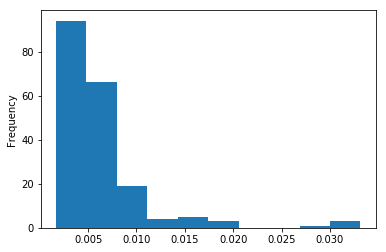

In [44]:
print('Skewness : ',p_df['MDVP:Jitter(%)'].skew())
print('Kurtosis : ',p_df['MDVP:Jitter(%)'].kurtosis())
print(p_df['MDVP:Jitter(%)'].plot.hist())


The value is positive hence the data is skewed towards right side

The value is positive hence more data points around the tail

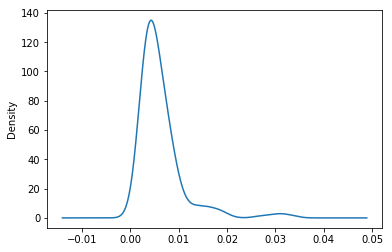

In [45]:
p_df ['MDVP:Jitter(%)'].plot.kde()

Outlier Treatment

In [46]:
q3 = p_df['MDVP:Jitter(%)'].quantile(0.75)
q1 = p_df['MDVP:Jitter(%)'].quantile(0.25)
t = q3-q1
outliers_above = q3+t
outliers_below = q1-t
print("outliers_above : {}".format(outliers_above))
print("outliers_below : {}".format(outliers_below))

outliers_above : 0.01127
outliers_below : -0.0004450000000000001


In [47]:
print(p_df['MDVP:Jitter(%)'].loc[p_df['MDVP:Jitter(%)']>outliers_above].count())
print(p_df['MDVP:Jitter(%)'].loc[p_df['MDVP:Jitter(%)']<outliers_below].count())
print(p_df['MDVP:Jitter(%)'].loc[p_df['MDVP:Jitter(%)']>outliers_above])

16
0
5      0.01284
98     0.01280
99     0.01378
100    0.01936
101    0.03316
102    0.01551
103    0.03011
147    0.01568
148    0.01466
149    0.01719
150    0.01627
151    0.01872
152    0.03107
153    0.02714
158    0.01813
193    0.01360
Name: MDVP:Jitter(%), dtype: float64


AxesSubplot(0.125,0.125;0.775x0.755)


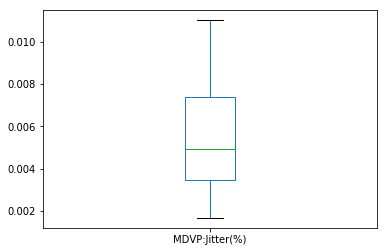

In [48]:
max_val = p_df['MDVP:Jitter(%)'].loc[p_df['MDVP:Jitter(%)']<=outliers_above].max()
p_df['MDVP:Jitter(%)'] = p_df['MDVP:Jitter(%)'].mask(p_df['MDVP:Jitter(%)']>outliers_above,max_val)
print(p_df['MDVP:Jitter(%)'].plot(kind='box'))

Skewness :  0.7135316854634219
Kurtosis :  -0.45799448113050856


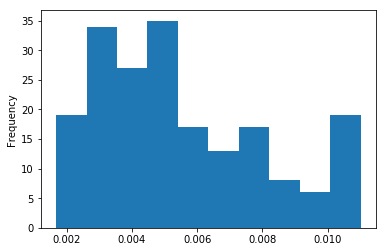

In [49]:
print('Skewness : ',p_df['MDVP:Jitter(%)'].skew())
print('Kurtosis : ',p_df['MDVP:Jitter(%)'].kurtosis())
p_df['MDVP:Jitter(%)'].plot.hist()

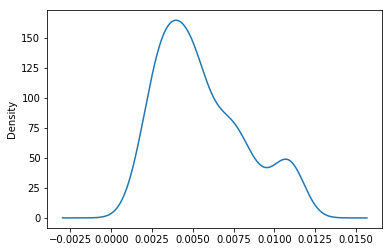

In [50]:
p_df ['MDVP:Jitter(%)'].plot.kde()


After outlier treatment kurtosis indicates less number of data points around the tail

MDVP:Jitter(Abs)

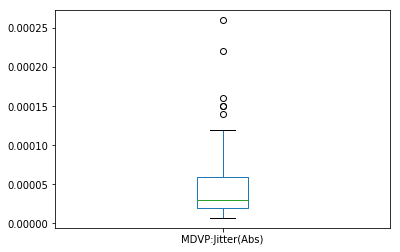

In [51]:

p_df['MDVP:Jitter(Abs)'].plot(kind='box')

Skewness :  2.6490714165257274
kurtosis :  10.869042517763667
AxesSubplot(0.125,0.125;0.775x0.755)


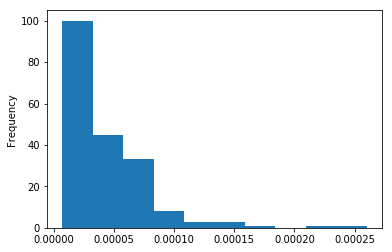

In [52]:
print('Skewness : ',p_df['MDVP:Jitter(Abs)'].skew())
print('kurtosis : ',p_df['MDVP:Jitter(Abs)'].kurtosis())
print(p_df['MDVP:Jitter(Abs)'].plot.hist())


The value is positive hence the data is skewed towards right side

The value is positive hence more data points are around the tail

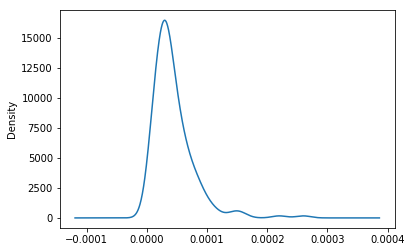

In [53]:
p_df ['MDVP:Jitter(Abs)'].plot.kde()

Outlier Treatment

In [54]:
q3 = p_df ['MDVP:Jitter(Abs)'].quantile(0.75)
q1 = p_df['MDVP:Jitter(Abs)'].quantile(0.25)
t = q3-q1
outliers_above = q3+t
outliers_below = q1-t
print("outliers_above : {}".format(outliers_above))
print("outliers_below : {}".format(outliers_below))


outliers_above : 9.999999999999999e-05
outliers_below : -1.9999999999999995e-05


In [55]:
print(p_df['MDVP:Jitter(Abs)'].loc[p_df['MDVP:Jitter(Abs)']>outliers_above].count())
print(p_df['MDVP:Jitter(Abs)'].loc[p_df['MDVP:Jitter(Abs)']<outliers_below].count())    

12
0


AxesSubplot(0.125,0.125;0.775x0.755)


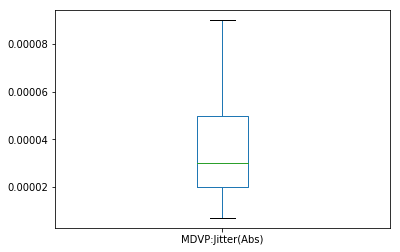

In [56]:
mean_val = p_df['MDVP:Jitter(Abs)'].loc[p_df['MDVP:Jitter(Abs)']<=outliers_above].mean()
p_df['MDVP:Jitter(Abs)'] = p_df['MDVP:Jitter(Abs)'].mask(p_df['MDVP:Jitter(Abs)']>outliers_above,mean_val)
print(p_df['MDVP:Jitter(Abs)'].plot(kind='box'))

skewness :  0.7300925097869511
Kurtosis :  0.008361144000160525


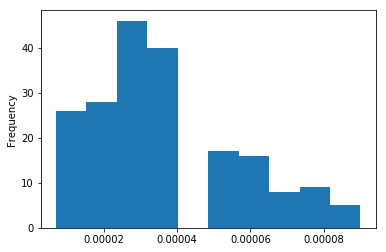

In [57]:
print('skewness : ',p_df['MDVP:Jitter(Abs)'].skew())
print('Kurtosis : ',p_df['MDVP:Jitter(Abs)'].kurtosis())
p_df['MDVP:Jitter(Abs)'].plot.hist()

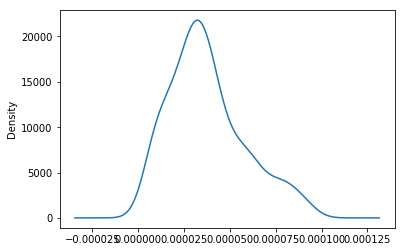

In [58]:
p_df ['MDVP:Jitter(Abs)'].plot.kde()

After outlier treatment kurtosis indicates less number of data points around the tail


MDVP:RAP

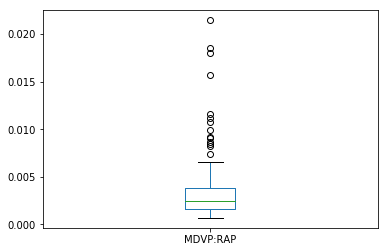

In [59]:
p_df ['MDVP:RAP'].plot(kind='box')

Skewness :  3.360708450480554
Kurtosis :  14.213797721522418
AxesSubplot(0.125,0.125;0.775x0.755)


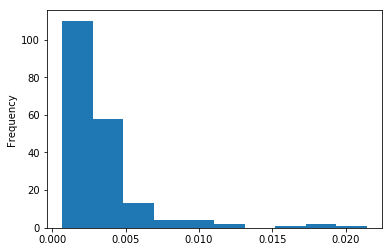

In [60]:
print('Skewness : ',p_df['MDVP:RAP'].skew())
print('Kurtosis : ',p_df['MDVP:RAP'].kurtosis())
print(p_df ['MDVP:RAP'].plot.hist())

The value is positive hence the data is skewed towards right side

The value is positive hence more data points are around the tail

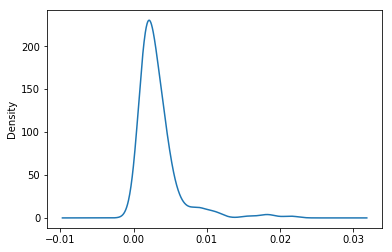

In [61]:
p_df ['MDVP:RAP'].plot.kde()

MDVP:PPQ

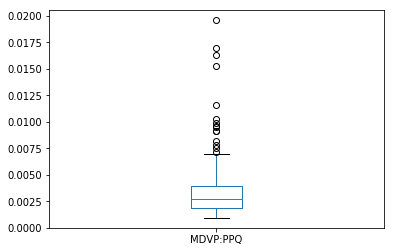

In [62]:
p_df ['MDVP:PPQ'].plot(kind='box')

Skewness :  3.073892457888517
Kurtosis :  11.963922120220282
AxesSubplot(0.125,0.125;0.775x0.755)
AxesSubplot(0.125,0.125;0.775x0.755)


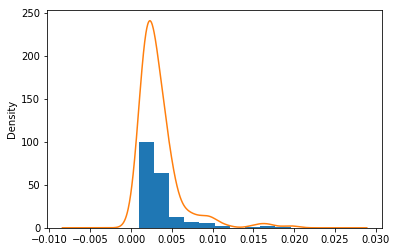

In [63]:
print('Skewness : ',p_df ['MDVP:PPQ'].skew())
print('Kurtosis : ',p_df ['MDVP:PPQ'].kurtosis())
print(p_df['MDVP:PPQ'].plot.hist())
print(p_df['MDVP:PPQ'].plot.kde())

The value is positive hence the data is skewed towards right side

The value is positive hence more data points are around the tail

Outlier Treatment

In [64]:
q3 = p_df['MDVP:PPQ'].quantile(0.75)
q1 = p_df['MDVP:PPQ'].quantile(0.25)
t = q3-q1
outliers_above = q3+t
outliers_below = q1-t
print("outliers_above : {}".format(outliers_above))
print("outliers_below : {}".format(outliers_below))

outliers_above : 0.00605
outliers_below : -0.00023499999999999997


In [65]:
print(p_df['MDVP:PPQ'].loc[p_df['MDVP:PPQ']>outliers_above].count())
print(p_df['MDVP:PPQ'].loc[p_df['MDVP:PPQ']<outliers_below].count())

19
0


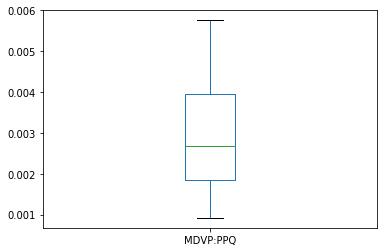

In [66]:
max_val =p_df['MDVP:PPQ'].loc[p_df['MDVP:PPQ']<=outliers_above].max()
p_df['MDVP:PPQ'] = p_df['MDVP:PPQ'].mask(p_df['MDVP:PPQ']>outliers_above,max_val)
p_df['MDVP:PPQ'].plot(kind='box')


Skewness :  0.6406137677940903
Kurtosis :  -0.6941626966478127
AxesSubplot(0.125,0.125;0.775x0.755)
AxesSubplot(0.125,0.125;0.775x0.755)


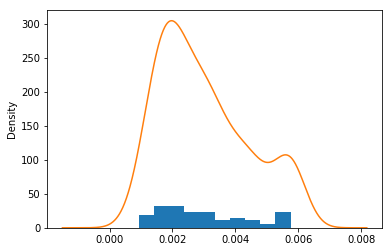

In [67]:
print('Skewness : ',p_df['MDVP:PPQ'].skew())
print('Kurtosis : ',p_df['MDVP:PPQ'].kurtosis())
print(p_df['MDVP:PPQ'].plot.hist())
print(p_df['MDVP:PPQ'].plot.kde())

Jitter:DDP

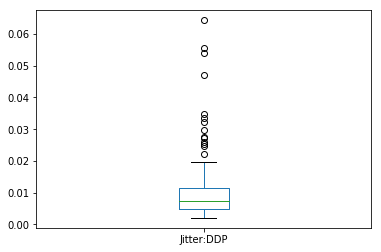

In [68]:
p_df ['Jitter:DDP'].plot(kind='box')

Skewness :  3.3620584478857203
Kurtosis :  14.224761911379424
AxesSubplot(0.125,0.125;0.775x0.755)
AxesSubplot(0.125,0.125;0.775x0.755)


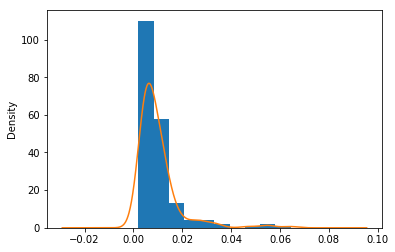

In [69]:
print('Skewness : ',p_df['Jitter:DDP'].skew())
print('Kurtosis : ',p_df['Jitter:DDP'].kurtosis())
print(p_df['Jitter:DDP'].plot.hist())
print(p_df['Jitter:DDP'].plot.kde())

The value is positive hence the data is skewed towards right side

The value is postive hence more data points are around the tail

Outlier Treatment

In [70]:
q3 = p_df['Jitter:DDP'].quantile(0.75)
q1 = p_df['Jitter:DDP'].quantile(0.25)
t = q3-q1
outliers_above = q3+t
outliers_below = q1-t
print("outliers_above : {}".format(outliers_above))
print("outliers_below : {}".format(outliers_below))

outliers_above : 0.018025
outliers_below : -0.001535


In [71]:
print(p_df['Jitter:DDP'].loc[p_df['Jitter:DDP']>outliers_above].count())
print(p_df['Jitter:DDP'].loc[p_df['Jitter:DDP']<outliers_below].count())

18
0


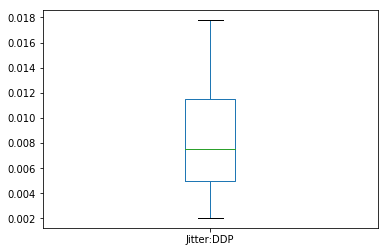

In [72]:
max_val = p_df ['Jitter:DDP'].loc[p_df['Jitter:DDP']<=outliers_above].max()
p_df['Jitter:DDP'] = p_df['Jitter:DDP'].mask(p_df['Jitter:DDP']>outliers_above,max_val)
p_df['Jitter:DDP'].plot(kind='box')

Skewness :  0.7360596525004133
Kurtosis :  -0.5082945859294927
AxesSubplot(0.125,0.125;0.775x0.755)
AxesSubplot(0.125,0.125;0.775x0.755)


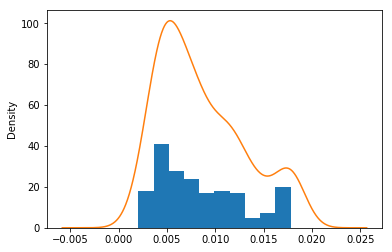

In [73]:
print('Skewness : ',p_df['Jitter:DDP'].skew())
print('Kurtosis : ',p_df['Jitter:DDP'].kurtosis())
print(p_df['Jitter:DDP'].plot.hist())
print(p_df['Jitter:DDP'].plot.kde())

After outlier treatment kurtosis indicates less number of data points around the tail

Three nonlinear measures of fundamental frequency variation

Spread1

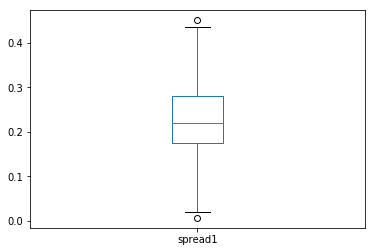

In [74]:
p_df ['spread1'].plot(kind='box')

Skewness :  0.14443048549278412
Kurtosis :  -0.08302289327680024
AxesSubplot(0.125,0.125;0.775x0.755)
AxesSubplot(0.125,0.125;0.775x0.755)


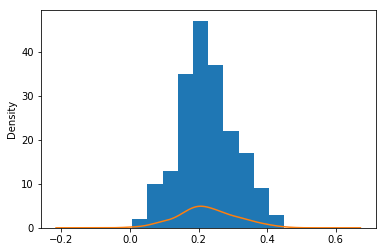

In [75]:
print('Skewness : ',p_df ['spread1'].skew())
print('Kurtosis : ',p_df['spread1'].kurtosis())
print(p_df['spread1'].plot.hist())
print(p_df['spread1'].plot.kde())

Spread2

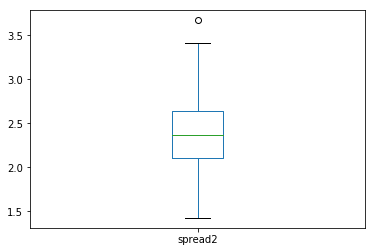

In [76]:
p_df ['spread2'].plot(kind='box')

Skewness :  0.4303838913329283
Kurtosis :  0.22033410480833515
AxesSubplot(0.125,0.125;0.775x0.755)
AxesSubplot(0.125,0.125;0.775x0.755)


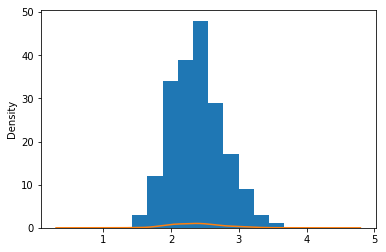

In [77]:
print('Skewness : ',p_df['spread2'].skew())
print('Kurtosis : ',p_df['spread2'].kurtosis())
print(p_df['spread2'].plot.hist())
print(p_df['spread2'].plot.kde())


Bivariate Analysis

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


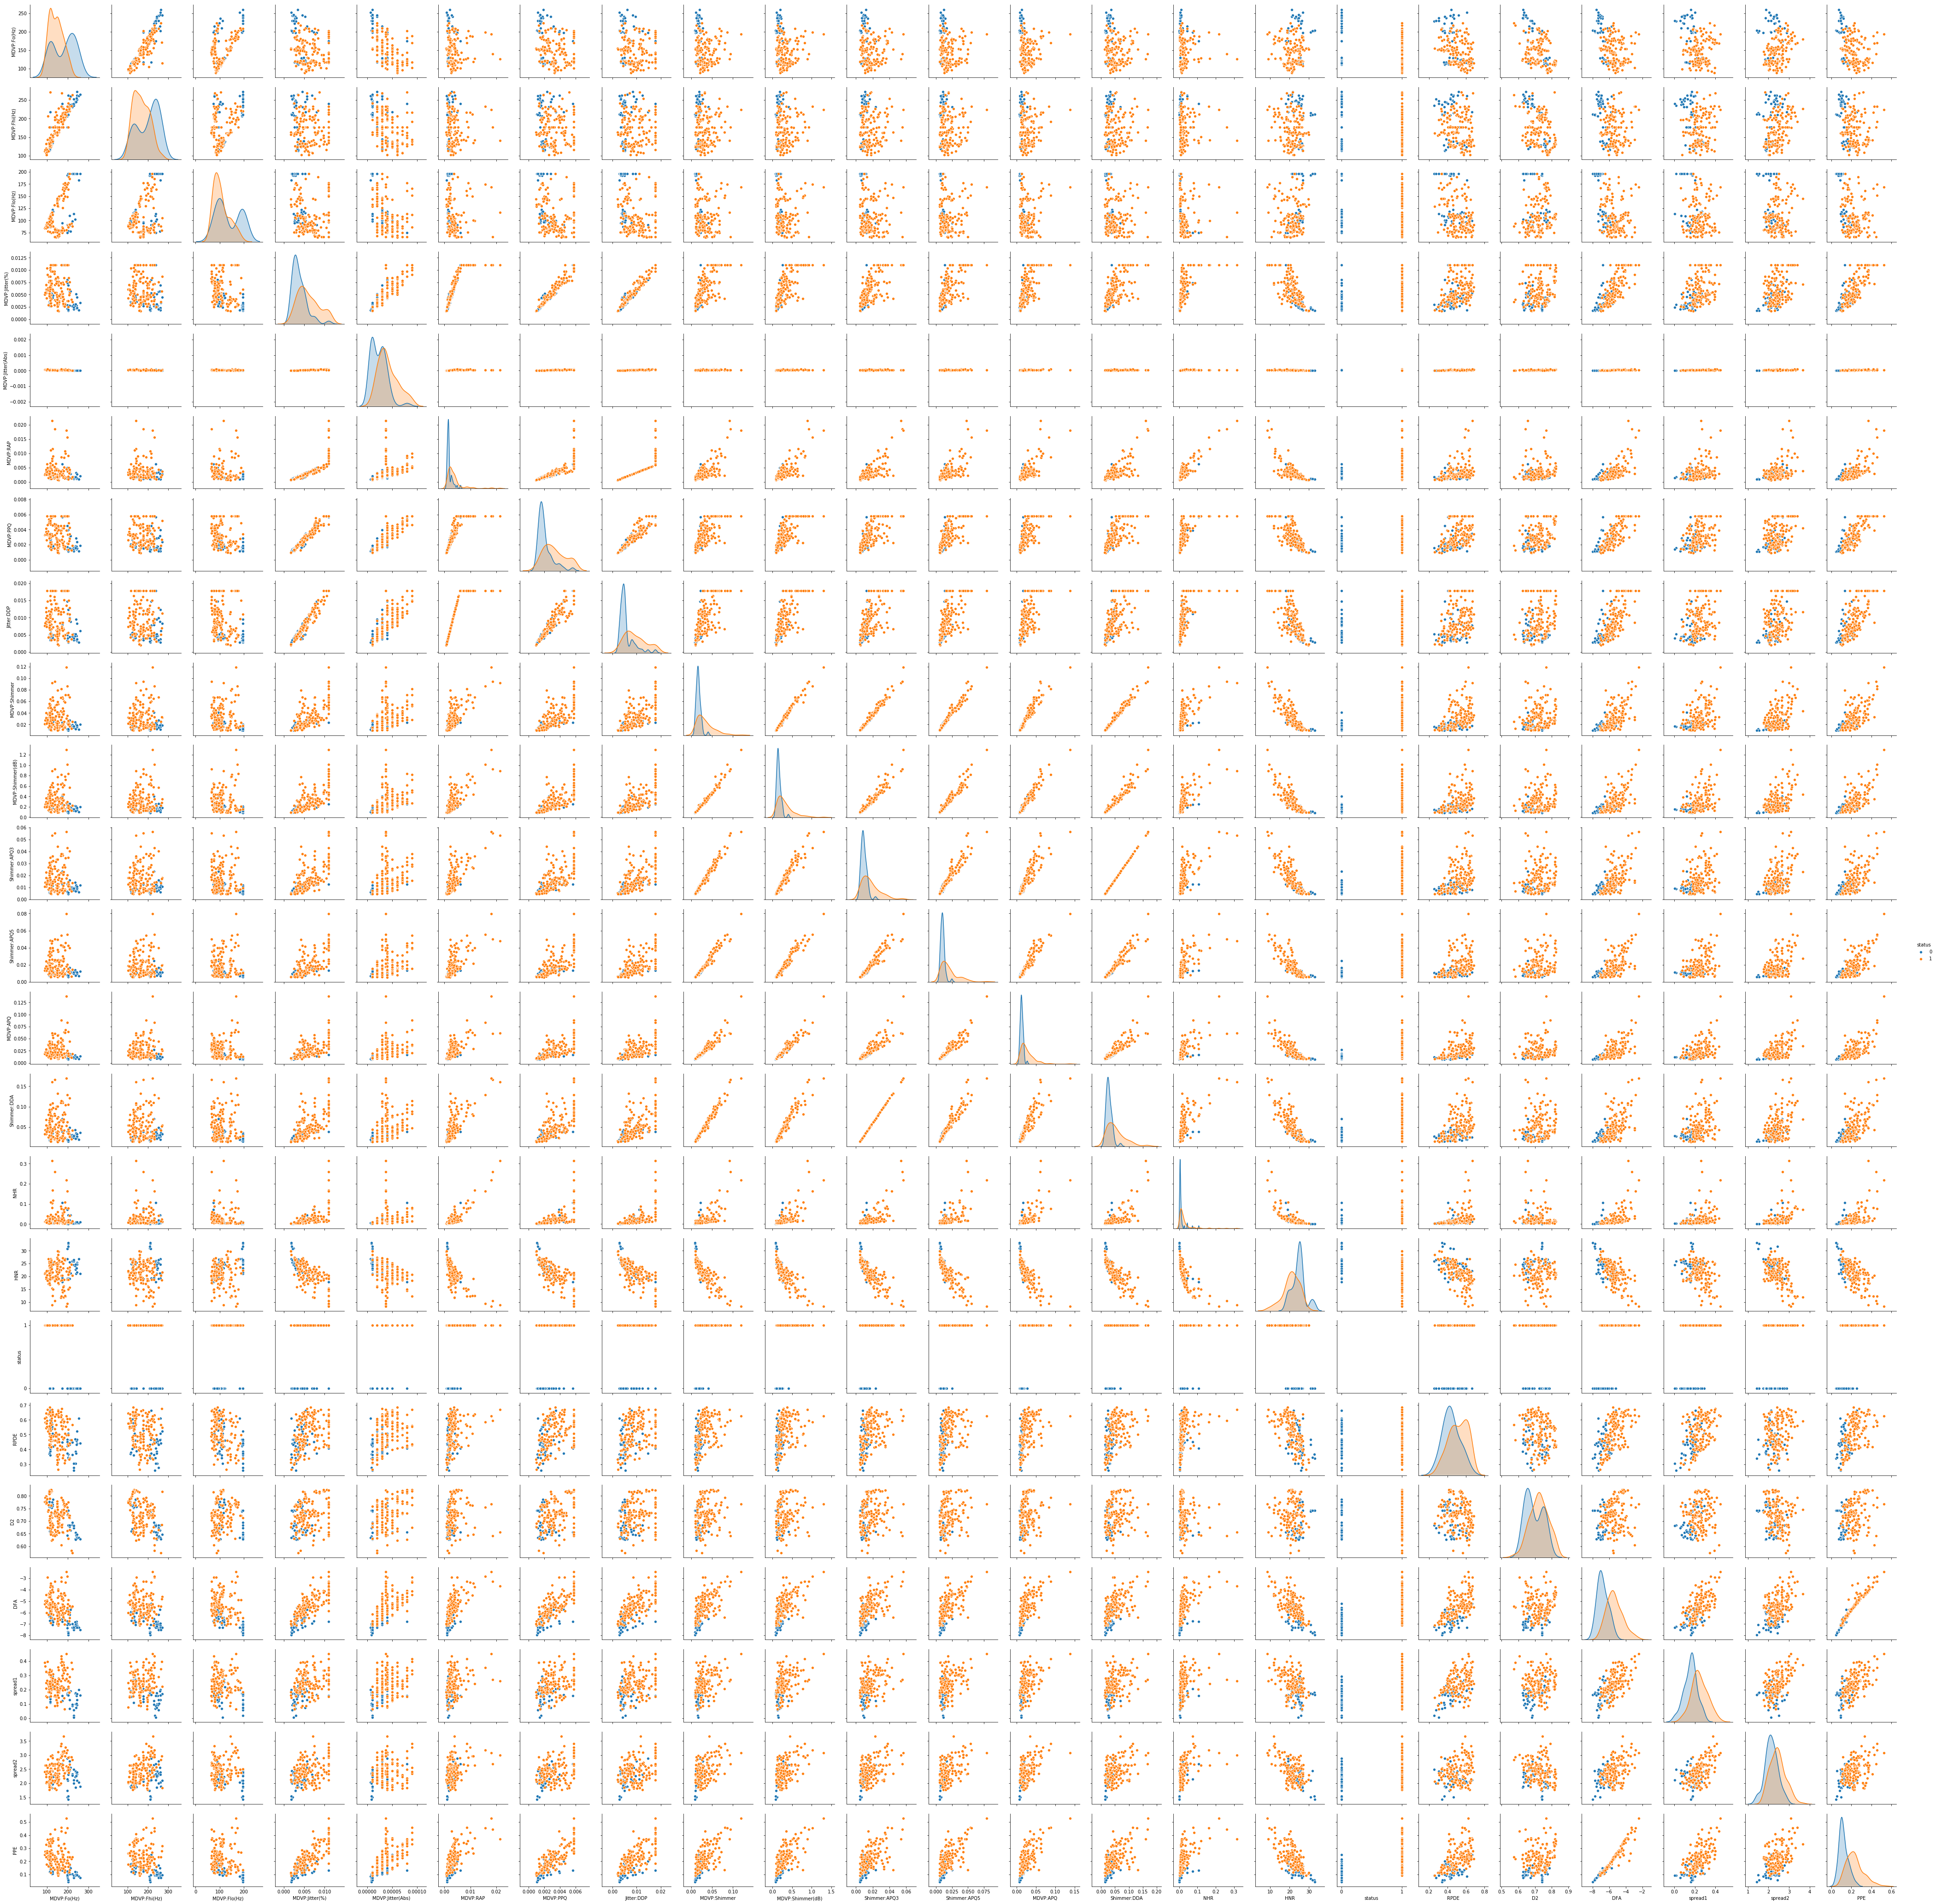

In [78]:
import seaborn as sns
sns.pairplot(p_df, hue = "status",diag_kind="kde")

In [79]:
p_df.corr()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,D2,DFA,spread1,spread2,PPE
MDVP:Fo(Hz),1.000000,0.880982,0.561371,-0.250583,-0.547372,-0.076194,-0.273418,-0.172984,-0.098374,-0.073742,...,-0.077774,-0.094732,-0.021981,0.059144,-0.383894,-0.446013,-0.413738,-0.249450,0.177980,-0.372356
MDVP:Fhi(Hz),0.880982,1.000000,0.377400,-0.142345,-0.407343,-0.030363,-0.143871,-0.085929,-0.037342,-0.012917,...,-0.013282,-0.037383,0.024090,-0.041859,-0.231960,-0.439904,-0.283326,-0.159403,0.230478,-0.241527
MDVP:Flo(Hz),0.561371,0.377400,1.000000,-0.323256,-0.431424,-0.086361,-0.300313,-0.270064,-0.126839,-0.100045,...,-0.082583,-0.137664,-0.098493,0.214699,-0.402776,0.009791,-0.372640,-0.207804,-0.089108,-0.317729
MDVP:Jitter(%),-0.250583,-0.142345,-0.323256,1.000000,0.764780,0.803458,0.972213,0.974055,0.680992,0.697224,...,0.644642,0.660841,0.635809,-0.725859,0.425158,0.217313,0.758064,0.423388,0.412113,0.769584
MDVP:Jitter(Abs),-0.547372,-0.407343,-0.431424,0.764780,1.000000,0.410835,0.774249,0.709354,0.427913,0.430953,...,0.407897,0.402661,0.225299,-0.456776,0.420964,0.408744,0.660562,0.407151,0.179888,0.659667
MDVP:RAP,-0.076194,-0.030363,-0.086361,0.803458,0.410835,1.000000,0.769777,0.813181,0.759581,0.790652,...,0.737455,0.744919,0.919521,-0.721543,0.342140,0.064083,0.648328,0.324407,0.426605,0.670999
MDVP:PPQ,-0.273418,-0.143871,-0.300313,0.972213,0.774249,0.769777,1.000000,0.949279,0.688001,0.699980,...,0.646506,0.667111,0.596246,-0.738289,0.430089,0.300069,0.774455,0.415703,0.374005,0.802770
Jitter:DDP,-0.172984,-0.085929,-0.270064,0.974055,0.709354,0.813181,0.949279,1.000000,0.673003,0.686114,...,0.625766,0.661542,0.633190,-0.733476,0.391978,0.182481,0.694455,0.326094,0.413472,0.700634
MDVP:Shimmer,-0.098374,-0.037342,-0.126839,0.680992,0.427913,0.759581,0.688001,0.673003,1.000000,0.987258,...,0.950083,0.987626,0.722194,-0.835271,0.447424,0.159954,0.654734,0.452025,0.507088,0.693771
MDVP:Shimmer(dB),-0.073742,-0.012917,-0.100045,0.697224,0.430953,0.790652,0.699980,0.686114,0.987258,1.000000,...,0.960977,0.963202,0.744477,-0.827805,0.410684,0.165157,0.652547,0.454314,0.512233,0.695058



After outlier Treatment

In [80]:
p_df.kurtosis(numeric_only  = True)

MDVP:Fo(Hz)         -0.627898
MDVP:Fhi(Hz)        -1.046282
MDVP:Flo(Hz)        -0.338062
MDVP:Jitter(%)      -0.457994
MDVP:Jitter(Abs)     0.008361
MDVP:RAP            14.213798
MDVP:PPQ            -0.694163
Jitter:DDP          -0.508295
MDVP:Shimmer         3.238308
MDVP:Shimmer(dB)     5.128193
Shimmer:APQ3         2.720152
Shimmer:APQ5         3.874210
MDVP:APQ            11.163288
Shimmer:DDA          2.720661
NHR                 21.994974
HNR                  0.616036
RPDE                -0.921781
D2                  -0.686152
DFA                 -0.050199
spread1             -0.083023
spread2              0.220334
PPE                  0.528335
dtype: float64

In [81]:
p_df.kurtosis(numeric_only  = True)

MDVP:Fo(Hz)         -0.627898
MDVP:Fhi(Hz)        -1.046282
MDVP:Flo(Hz)        -0.338062
MDVP:Jitter(%)      -0.457994
MDVP:Jitter(Abs)     0.008361
MDVP:RAP            14.213798
MDVP:PPQ            -0.694163
Jitter:DDP          -0.508295
MDVP:Shimmer         3.238308
MDVP:Shimmer(dB)     5.128193
Shimmer:APQ3         2.720152
Shimmer:APQ5         3.874210
MDVP:APQ            11.163288
Shimmer:DDA          2.720661
NHR                 21.994974
HNR                  0.616036
RPDE                -0.921781
D2                  -0.686152
DFA                 -0.050199
spread1             -0.083023
spread2              0.220334
PPE                  0.528335
dtype: float64

Storing the Processed Data into a CSV file

In [82]:
p_df.to_csv('cleaned-data.csv')

# Q4 Split the dataset into training and test set in the ratio of 70:30

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import cross_val_score
from scipy.stats import zscore

In [85]:
cleaned_data = pd.read_csv('cleaned-data.csv')

In [86]:
# capture the target column ("status") into separate vectors for training set and test set

X = cleaned_data[['MDVP:Fo(Hz)','MDVP:Fhi(Hz)','MDVP:Flo(Hz)','MDVP:Jitter(%)','MDVP:Jitter(Abs)','MDVP:RAP','MDVP:PPQ','Jitter:DDP','MDVP:Shimmer','MDVP:Shimmer(dB)','Shimmer:APQ3','Shimmer:APQ5','MDVP:APQ','Shimmer:DDA','NHR','HNR','RPDE','DFA','spread1','spread2','D2','PPE']]

y = cleaned_data["status"]

In [88]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Q5 Creating the model using “entropy” method of reducing the entropy and fit it to training data

In [159]:
# decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion = 'entropy' )

In [160]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [161]:
cleaned_data.dtypes

Unnamed: 0            int64
name                 object
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status                int64
RPDE                float64
D2                  float64
DFA                 float64
spread1             float64
spread2             float64
PPE                 float64
dtype: object

Testing the model on test data

In [162]:
y_predict_train = dt_model.predict(X_train)
y_predict_test = dt_model.predict(X_test)


# Q6 Capturing the predicted values and displaying it in a crosstab

In [163]:
accuracy_train = accuracy_score(y_predict_train, y_train)
accuracy_test = accuracy_score(y_predict_test, y_test)
print ("train accuracy_dt") 
print (accuracy_train)
print ("test_accuracy_dt")
print (accuracy_test)
train_cm = metrics.confusion_matrix(y_train,y_predict_train)
print ("confusion matrix : train data - dt")
print(train_cm)
test_cm = metrics.confusion_matrix(y_test,y_predict_test)
print ("confusion matrix : test data - dt")
print(test_cm)
trainF1score = f1_score(y_train,y_predict_train)
testF1score = f1_score(y_test,y_predict_test)
print ("f1 score: train data - dt")
print(trainF1score)
test_cm = metrics.confusion_matrix(y_test,y_predict_test)
print ("f1 score : test data - dt")
print(testF1score)

train accuracy_dt
1.0
test_accuracy_dt
0.8813559322033898
confusion matrix : train data - dt
[[ 36   0]
 [  0 100]]
confusion matrix : test data - dt
[[ 9  3]
 [ 4 43]]
f1 score: train data - dt
1.0
f1 score : test data - dt
0.924731182795699


# Q7 Regularising the Decision Tree

there are multiple forms of regularising, let us understand what are those running the same data and plotting AUC graphs across.

#max_depth
The first parameter to tune is max_depth. This indicates how deep the tree can be. The deeper the tree, the more splits it has and it captures more information about the data. We fit a decision tree with depths ranging from 1 to 32 and plot the training and test auc scores.

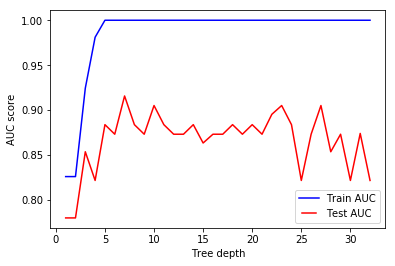

In [164]:
import matplotlib as mpl
import matplotlib.pyplot as plt
max_depths = np.linspace(1, 32, 32, endpoint=True)
train_results = []
test_results = []
for max_depth in max_depths:
   dt = DecisionTreeClassifier(max_depth=max_depth)
   dt.fit(X_train, y_train)
   train_pred = dt.predict(X_train)
   false_positive_rate, true_positive_rate, thresholds = roc_curve(y_train, train_pred)
   roc_auc = auc(false_positive_rate, true_positive_rate)
   # Add auc score to previous train results
   train_results.append(roc_auc)
   y_pred = dt.predict(X_test)
   false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred)
   roc_auc = auc(false_positive_rate, true_positive_rate)
   # Add auc score to previous test results
   test_results.append(roc_auc)
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(max_depths, train_results,'b', label="Train AUC")
#line2, = plt.plot(max_depths, test_results, 'b', label="Test AUC”)
line1, = plt.plot(max_depths, test_results,'r', label="Test AUC")
                  
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel("AUC score")
plt.xlabel("Tree depth")
plt.show()

# We see that our model overfits for large depth values. The tree perfectly predicts all of the train data, however, it fails to generalize the findings for new data

# min_samples_split
min_samples_split represents the minimum number of samples required to split an internal node. This can vary between considering at least one sample at each node to considering all of the samples at each node. When we increase this parameter, the tree becomes more constrained as it has to consider more samples at each node. Here we will vary the parameter from 10% to 100% of the samples

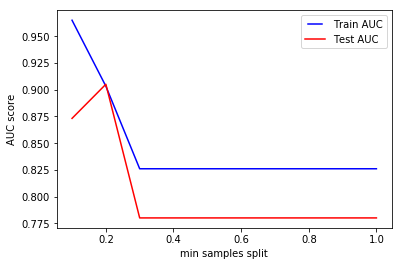

In [165]:
min_samples_splits = np.linspace(0.1, 1.0, 10, endpoint=True)
train_results = []
test_results = []
for min_samples_split in min_samples_splits:
   dt = DecisionTreeClassifier(min_samples_split=min_samples_split)
   dt.fit(X_train, y_train)
   train_pred = dt.predict(X_train)
   false_positive_rate, true_positive_rate, thresholds =    roc_curve(y_train, train_pred)
   roc_auc = auc(false_positive_rate, true_positive_rate)
   train_results.append(roc_auc)
   y_pred = dt.predict(X_test)
   false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred)
   roc_auc = auc(false_positive_rate, true_positive_rate)
   test_results.append(roc_auc)
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(min_samples_splits, train_results, 'b' , label= "Train AUC")
line2, = plt.plot(min_samples_splits, test_results, 'r', label="Test AUC")
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel("AUC score")
plt.xlabel("min samples split")
plt.show()

# We can clearly see that when we consider 100% of the samples at each node, the model cannot learn enough about the data. This is an underfitting case.

# min_samples_leaf
min_samples_leaf is The minimum number of samples required to be at a leaf node. This parameter is similar to min_samples_splits, however, this describe the minimum number of samples of samples at the leafs, the base of the tree.

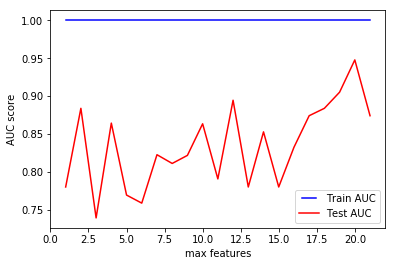

In [166]:
max_features = list(range(1,X_train.shape[1]))
train_results = []
test_results = []
for max_feature in max_features:
   dt = DecisionTreeClassifier(max_features=max_feature)
   dt.fit(X_train, y_train)
   train_pred = dt.predict(X_train)
   false_positive_rate, true_positive_rate, thresholds = roc_curve(y_train, train_pred)
   roc_auc = auc(false_positive_rate, true_positive_rate)
   train_results.append(roc_auc)
   y_pred = dt.predict(X_test)
   false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred)
   roc_auc = auc(false_positive_rate, true_positive_rate)
   test_results.append(roc_auc)
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(max_features, train_results, 'b', label="Train AUC")
line2, = plt.plot(max_features, test_results, 'r', label="Test AUC")
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel("AUC score")
plt.xlabel("max features")
plt.show()

# This is also an overfitting case. It’s unexpected to get overfitting for all values of max_features. However, according to sklearn documentation for decision tree, the search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than max_features features.

Using max_depth for the purpose of this exercise and comparison

In [167]:
reg_dt_model = DecisionTreeClassifier(criterion = 'entropy', max_depth = 10)
reg_dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=10,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [168]:
y_predict_train = reg_dt_model.predict(X_train)
y_predict_test = reg_dt_model.predict(X_test)

In [169]:
accuracy_train = accuracy_score(y_predict_train, y_train)
accuracy_test = accuracy_score(y_predict_test, y_test)
print ("train accuracy dt-regularised general") 
print (accuracy_train)
print ("test_accuracy dt-regularised general")
print (accuracy_test)
train_cm = metrics.confusion_matrix(y_train,y_predict_train)
print ("confusion matrix : train data - dt regularised general")
print(train_cm)
test_cm = metrics.confusion_matrix(y_test,y_predict_test)
print ("confusion matrix : test data - dt regularised general")
print(test_cm)
trainF1score = f1_score(y_train,y_predict_train)
testF1score = f1_score(y_test,y_predict_test)
print ("f1 score: train data - dt-regularised general")
print(trainF1score)
test_cm = metrics.confusion_matrix(y_test,y_predict_test)
print ("f1 score : test data - dt - regularised general")
print(testF1score)

train accuracy dt-regularised general
1.0
test_accuracy dt-regularised general
0.8813559322033898
confusion matrix : train data - dt regularised general
[[ 36   0]
 [  0 100]]
confusion matrix : test data - dt regularised general
[[10  2]
 [ 5 42]]
f1 score: train data - dt-regularised general
1.0
f1 score : test data - dt - regularised general
0.9230769230769231


# The inDepth series investigates how model parameters affect performance in term of overfitting and underfitting. Next one will be for Random Forrest.

# Q8 Random Forest

In [170]:
from sklearn.ensemble import RandomForestClassifier
rfcl = RandomForestClassifier(n_estimators = 1)
rfcl = rfcl.fit(X_train, y_train)

In [171]:
y_predict_train = rfcl.predict(X_train)
y_predict_test = rfcl.predict(X_test)

In [172]:
accuracy_train = accuracy_score(y_predict_train, y_train)
accuracy_test = accuracy_score(y_predict_test, y_test)
print ("train accuracy RF") 
print (accuracy_train)
print ("test_accuracy RF")
print (accuracy_test)
train_cm = metrics.confusion_matrix(y_train,y_predict_train)
print ("confusion matrix : train data -  RF")
print(train_cm)
test_cm = metrics.confusion_matrix(y_test,y_predict_test)
print ("confusion matrix : test data -  RF")
print(test_cm)
trainF1score = f1_score(y_train,y_predict_train)
testF1score = f1_score(y_test,y_predict_test)
print ("f1 score: train data -  RF")
print(trainF1score)
test_cm = metrics.confusion_matrix(y_test,y_predict_test)
print ("f1 score : test data -  RF")
print(testF1score)

train accuracy RF
0.9044117647058824
test_accuracy RF
0.711864406779661
confusion matrix : train data -  RF
[[30  6]
 [ 7 93]]
confusion matrix : test data -  RF
[[ 7  5]
 [12 35]]
f1 score: train data -  RF
0.9346733668341709
f1 score : test data -  RF
0.8045977011494252


In [173]:
#Perform Grid Search Method to find the optimal max_depth size  {for Decision Tree}
from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.arange(1,10),'criterion' : ['entropy']}
GS=GridSearchCV(reg_dt_model,parameter,cv=3)
GS.fit(X,y)

GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=10,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [174]:
GS.best_params_

{'criterion': 'entropy', 'max_depth': 8}

In [175]:
reg_dt_model2 = DecisionTreeClassifier(criterion = 'entropy', max_depth = 8)
reg_dt_model2.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=8,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [176]:
y_predict_train = rfcl.predict(X_train)
y_predict_test = rfcl.predict(X_test)

In [177]:
accuracy_train = accuracy_score(y_predict_train, y_train)
accuracy_test = accuracy_score(y_predict_test, y_test)
print ("train accuracy_dt_Grid_Search") 
print (accuracy_train)
print ("test_accuracy_dt_Grid_Search")
print (accuracy_test)
train_cm = metrics.confusion_matrix(y_train,y_predict_train)
print ("confusion matrix : train data - dt Grid_Search")
print(train_cm)
test_cm = metrics.confusion_matrix(y_test,y_predict_test)
print ("confusion matrix : test data - dt Grid_Search")
print(test_cm)
trainF1score = f1_score(y_train,y_predict_train)
testF1score = f1_score(y_test,y_predict_test)
print ("f1 score: train data -dt Grid Search")
print(trainF1score)
test_cm = metrics.confusion_matrix(y_test,y_predict_test)
print ("f1 score : test data -  dt Grid Search")
print(testF1score)

train accuracy_dt_Grid_Search
0.9044117647058824
test_accuracy_dt_Grid_Search
0.711864406779661
confusion matrix : train data - dt Grid_Search
[[30  6]
 [ 7 93]]
confusion matrix : test data - dt Grid_Search
[[ 7  5]
 [12 35]]
f1 score: train data -dt Grid Search
0.9346733668341709
f1 score : test data -  dt Grid Search
0.8045977011494252


In [178]:
#Perform Grid Search Method to find the optimal max_depth size {for Random Forest}
from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.arange(1,10),'criterion' : ['entropy']}
GS=GridSearchCV(rfcl,parameter,cv=3)
GS.fit(X,y)

GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=1, n_jobs=None,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [179]:
GS.best_params_

{'criterion': 'entropy', 'max_depth': 3}

In [180]:
from sklearn.ensemble import RandomForestClassifier
rfcl2 = RandomForestClassifier(n_estimators = 3)
rfcl2 = rfcl.fit(X_train, y_train)

In [181]:
y_predict_train = rfcl.predict(X_train)
y_predict_test = rfcl.predict(X_test)

In [182]:
accuracy_train = accuracy_score(y_predict_train, y_train)
accuracy_test = accuracy_score(y_predict_test, y_test)
print ("train accuracy RF Grid_search") 
print (accuracy_train)
print ("test_accuracy RF Grid_search")
print (accuracy_test)
train_cm = metrics.confusion_matrix(y_train,y_predict_train)
print ("confusion matrix : train data - RF Grid_search")
print(train_cm)
test_cm = metrics.confusion_matrix(y_test,y_predict_test)
print ("confusion matrix : test data - RF Grid_search")
print(test_cm)
trainF1score = f1_score(y_train,y_predict_train)
testF1score = f1_score(y_test,y_predict_test)
print ("f1 score: train data -RF Grid_search")
print(trainF1score)
test_cm = metrics.confusion_matrix(y_test,y_predict_test)
print ("f1 score : test data -  RF Grid_search")
print(testF1score)

train accuracy RF Grid_search
0.9558823529411765
test_accuracy RF Grid_search
0.8983050847457628
confusion matrix : train data - RF Grid_search
[[32  4]
 [ 2 98]]
confusion matrix : test data - RF Grid_search
[[ 6  6]
 [ 0 47]]
f1 score: train data -RF Grid_search
0.9702970297029702
f1 score : test data -  RF Grid_search
0.9400000000000001


accuracy with Decision tree used along with Grid Search :0.7118
accuracy with Decision tree used without Grid Search:0.88
accuracy with regularisation Decision tree used without Grid Search:0.88

accuracy with Random Forest used along with Grid Search : 0.799
accuracy with Random Forest without Grid Search : 0.71

False negatives are more in Decision tree than Random tree. Random Forest is better that way

F1 data : 
Decision tree  0.9247
Decision tree regularised 0.9231
Random Forest: 0.8046
Decision tree with Grid Search:0.8046
Random Forest with Grid Search:0.940
F1 data with RF + Grid Search is the best


# Best model is to use Random Forest along with Grid Search as can be observed